[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.288586  24.757340  23.848711  24.746232  212818400
2015-01-05  23.604332  24.137513  23.417720  24.057535  257142000
2015-01-06  23.606554  23.866479  23.244435  23.668758  263188400
2015-01-07  23.937576  24.037547  23.704309  23.815388  160423600
2015-01-08  24.857315  24.915077  24.148629  24.266374  237458000


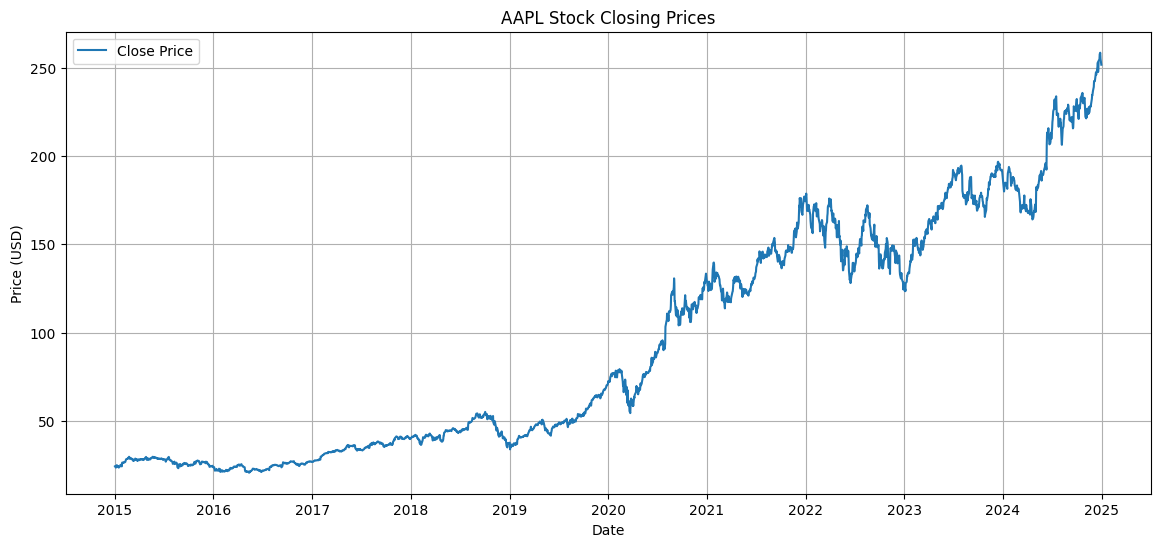

In [21]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2024-12-31"

data = yf.download(ticker, start=start_date, end=end_date)

print(data.head())
plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
def add_indicators(df):
    df = df.copy()
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df.fillna(method='bfill', inplace=True)

    return df

data = add_indicators(data)
print(data[['Close', 'RSI', 'MA20']].head())


Price           Close        RSI       MA20
Ticker           AAPL                      
Date                                       
2015-01-02  24.288586  56.613516  24.579943
2015-01-05  23.604332  56.613516  24.579943
2015-01-06  23.606554  56.613516  24.579943
2015-01-07  23.937576  56.613516  24.579943
2015-01-08  24.857315  56.613516  24.579943


C:\Users\praja\AppData\Local\Temp\ipykernel_18440\1453370586.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

feature_data = data[['Close', 'RSI', 'MA20']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(feature_data)

sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 0]) 

X = np.array(X)
y = np.array(y)

print(f"Final LSTM input shape: {X.shape} | Output shape: {y.shape}")


Final LSTM input shape: (2455, 60, 3) | Output shape: (2455,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(1)) 

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20


c:\Users\praja\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0203 - val_loss: 0.0019
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0016 - val_loss: 9.8733e-04
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0017 - val_loss: 0.0086
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0012 - val_loss: 0.0031
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012 - val_loss: 0.0072
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0010 - val_loss: 0.0103
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0012 - v

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


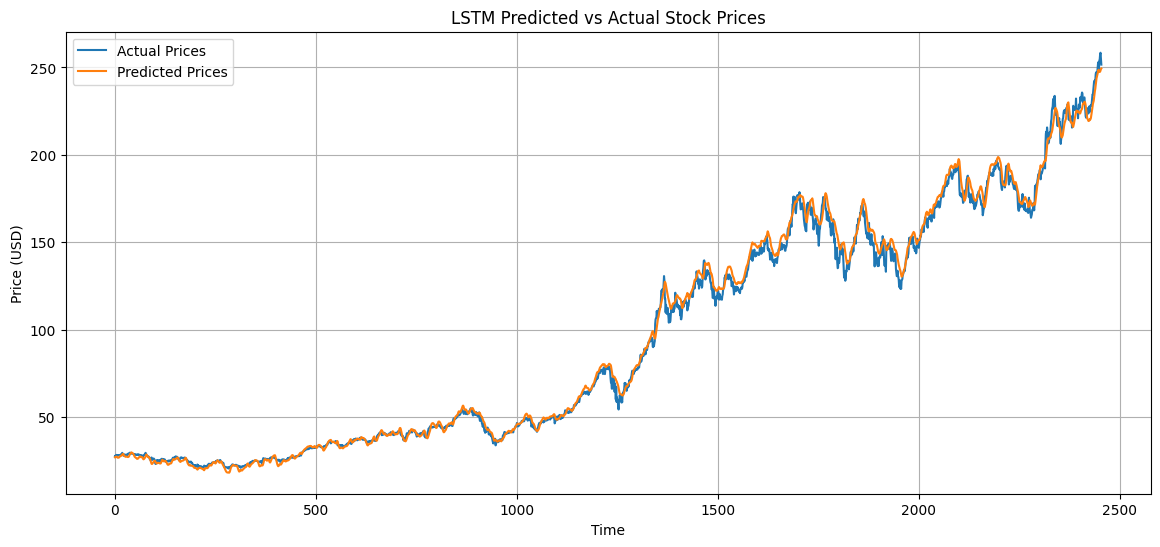

In [25]:

predicted_prices = model.predict(X)
padding = np.zeros((predicted_prices.shape[0], 2))  # 2 = RSI + MA20
predicted_full = np.concatenate((predicted_prices, padding), axis=1)
predicted_prices_actual = scaler.inverse_transform(predicted_full)[:, 0] 


actual_prices_full = np.concatenate((y.reshape(-1, 1), padding), axis=1)
actual_prices_actual = scaler.inverse_transform(actual_prices_full)[:, 0]

plt.figure(figsize=(14, 6))
plt.plot(actual_prices_actual, label='Actual Prices')
plt.plot(predicted_prices_actual, label='Predicted Prices')
plt.title("LSTM Predicted vs Actual Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
model.save("lstm_stock_model.h5")


[*********************100%***********************]  1 of 1 completed
C:\Users\praja\AppData\Local\Temp\ipykernel_18440\1453370586.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


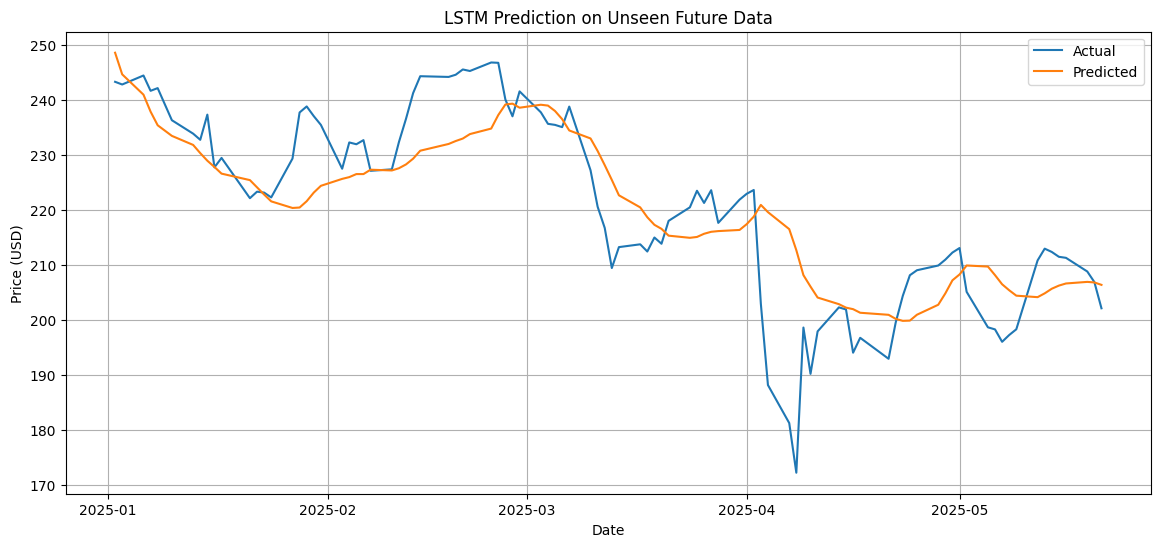

In [ ]:
import yfinance as yf
import datetime
from tensorflow.keras.models import load_model
import pandas as pd
model = load_model("lstm_stock_model.h5")

ticker = "AAPL"
start_date = "2025-01-01"
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

new_data = yf.download(ticker, start=start_date, end=end_date)
new_data = add_indicators(new_data)

combined_data = pd.concat([data[['Close', 'RSI', 'MA20']].iloc[-60:], new_data[['Close', 'RSI', 'MA20']]], axis=0)

combined_scaled = scaler.transform(combined_data)
X_test = []
for i in range(60, len(combined_scaled)):
    X_test.append(combined_scaled[i-60:i])
X_test = np.array(X_test)

predictions = model.predict(X_test)


padding = np.zeros((predictions.shape[0], 2))
pred_full = np.concatenate((predictions, padding), axis=1)
predicted_prices = scaler.inverse_transform(pred_full)[:, 0]
plt.figure(figsize=(14, 6))
plt.plot(new_data.index[-len(predicted_prices):], new_data['Close'][-len(predicted_prices):], label='Actual')
plt.plot(new_data.index[-len(predicted_prices):], predicted_prices, label='Predicted')
plt.title("LSTM Prediction on Unseen Future Data")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()
